# Load the data from Kaggle


In this notebook, we sometimes refer to SpeedCP as LAKCP.

In [ ]:
import kagglehub
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os
from torch.optim import SGD
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.extend([parent_dir])

# Download latest version
# path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
# print("Path to dataset files:", path)
#print(os.getcwd())

In [2]:
# #Device agnostic code
if torch.cuda.is_available():
    device = "cuda" 
else:
    device = "cpu" 
# #### load the data from the pt file
MRI = torch.load("MRI.pt", weights_only=False)
MRI_train_dataset = torch.load("mri_train.pt", weights_only=False)
MRI_calib_dataset = torch.load("mri_calib.pt", weights_only=False)
MRI_test_dataset  = torch.load("mri_test.pt", weights_only=False)

print("MRI Training set size:", len(MRI_train_dataset))
print("MRI Calibration set size:", len(MRI_calib_dataset))
print("MRI Testing set size:", len(MRI_test_dataset))

MRI_train_loader = DataLoader(MRI_train_dataset, batch_size=32, shuffle=True)
# Model for FeatureCP comparison - separating feature extractor and classifier head
from method_comparison import MRIModelFCP
model = MRIModelFCP(in_channels=3, num_classes=2)
model.load_state_dict(torch.load("mri_model.pth", map_location=device))
model = model.to(device)

MRI_test_loader = DataLoader(MRI_test_dataset, batch_size=32, shuffle=True)

MRI Training set size: 2000
MRI Calibration set size: 2400
MRI Testing set size: 600


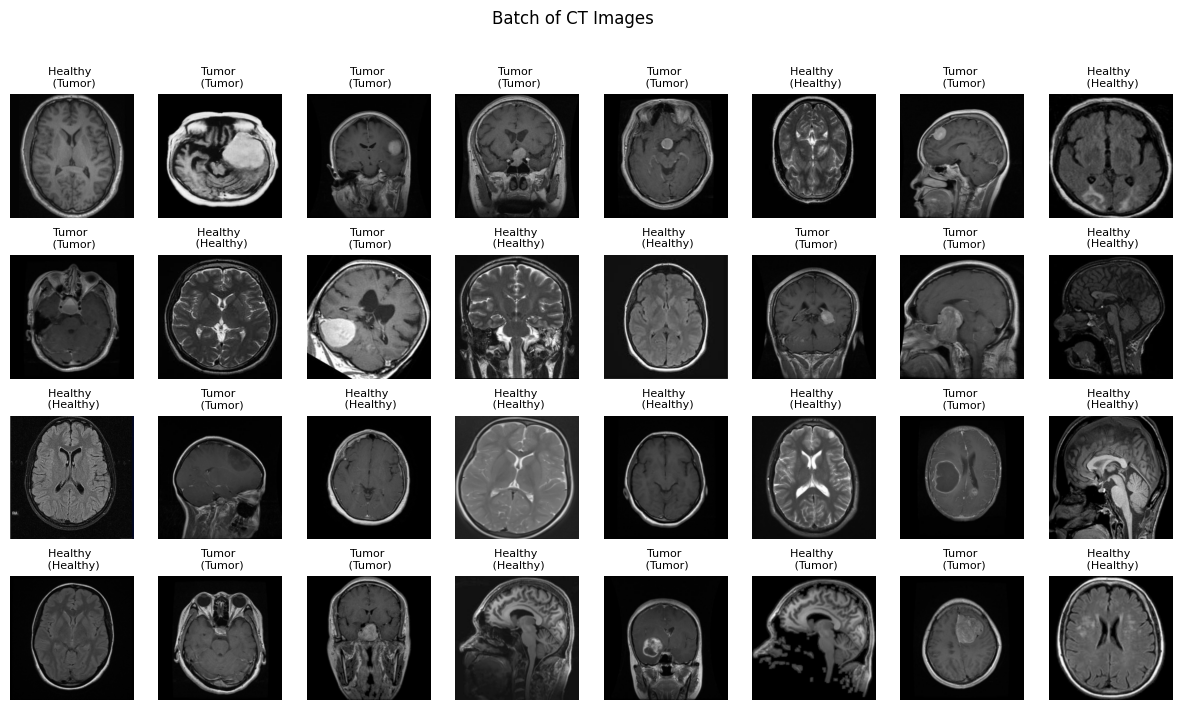

In [3]:

def show_MRI_batch(dataloader, title="Batch of CT Images"):
    images, labels = next(iter(dataloader))
#
    fig, axes = plt.subplots(4, 8, figsize=(15, 8))
    fig.suptitle(title)
    
    for i, ax in enumerate(axes.flatten()):
        if i < 32:
            img = images[i].permute(1, 2, 0)  # Convert tensor image for plotting
            predicted_label = model(images[i].unsqueeze(0).to(device)).argmax(dim=1).item()
            ax.imshow(img)
            ax.set_title(f"{MRI.classes[labels[i]]} \n ({MRI.classes[predicted_label]})", fontsize=8)
            ax.axis('off')
    plt.show()
show_MRI_batch(MRI_test_loader)

## Predictive model evaluation

Evaluating Test: 100%|██████████| 19/19 [02:31<00:00,  7.96s/it]



Model Accuracy Results:
Training Accuracy: 94.40%
Calibration Accuracy: 94.54%
Test Accuracy: 92.67%


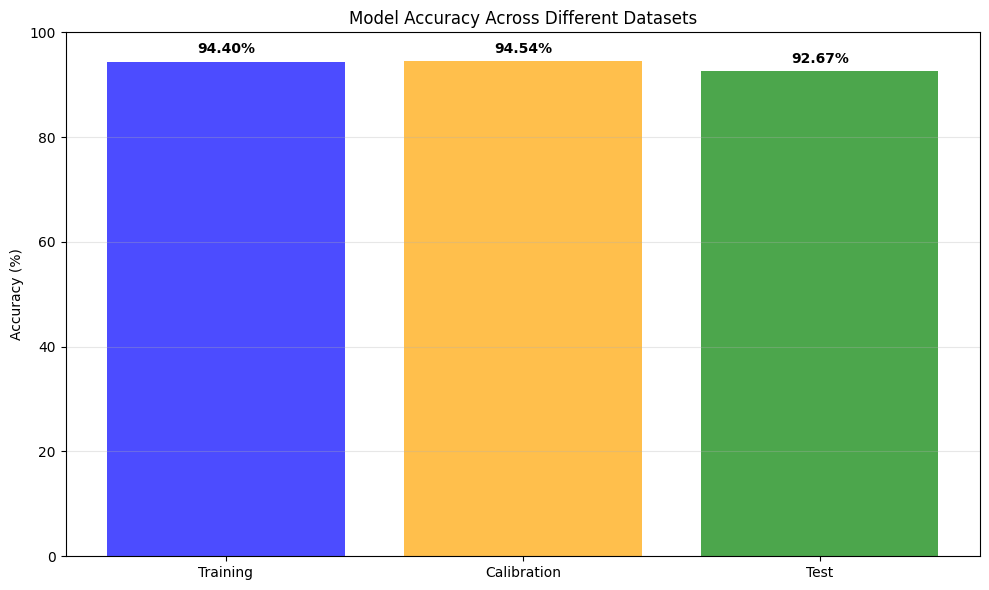

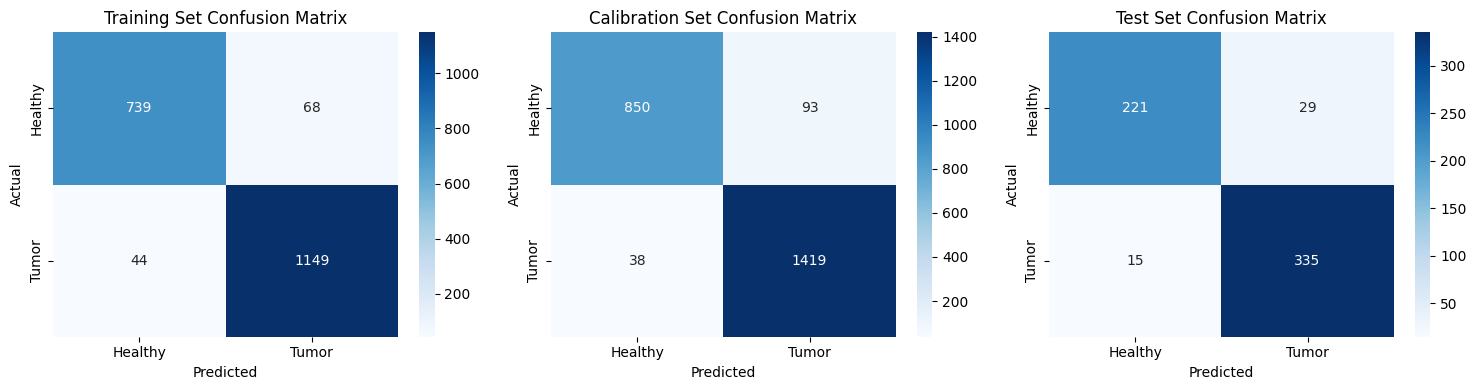

In [11]:
# Evaluate model accuracy on different datasets
def evaluate_model(model, dataloader, dataset_name):
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Evaluating {dataset_name}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    return accuracy, all_predictions, all_labels

# Create data loaders for evaluation
MRI_calib_loader = DataLoader(MRI_calib_dataset, batch_size=32, shuffle=False)
MRI_test_loader = DataLoader(MRI_test_dataset, batch_size=32, shuffle=False)

# Evaluate on all datasets
train_acc, train_pred, train_labels = evaluate_model(model, MRI_train_loader, "Training")
calib_acc, calib_pred, calib_labels = evaluate_model(model, MRI_calib_loader, "Calibration")
test_acc, test_pred, test_labels = evaluate_model(model, MRI_test_loader, "Test")

print(f"\nModel Accuracy Results:")
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Calibration Accuracy: {calib_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

# Visualize accuracy comparison
import matplotlib.pyplot as plt

datasets = ['Training', 'Calibration', 'Test']
accuracies = [train_acc, calib_acc, test_acc]

plt.figure(figsize=(10, 6))
bars = plt.bar(datasets, accuracies, color=['blue', 'orange', 'green'], alpha=0.7)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Across Different Datasets')
plt.ylim(0, 100)

# Add accuracy values on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (pred, labels, name) in enumerate([(train_pred, train_labels, 'Training'),
                                         (calib_pred, calib_labels, 'Calibration'),
                                         (test_pred, test_labels, 'Test')]):
    cm = confusion_matrix(labels, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Set Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(MRI.classes)
    axes[i].set_yticklabels(MRI.classes)

plt.tight_layout()
plt.show()


In [ ]:
import sys
from speedcp import SpeedCP
from PCP.utils import PCP, RLCP
from conditionalconformal.condconf import CondConf
from method_comparison import cp_calibrate_and_eval, score_function, get_output_dict


## Conformal Prediction using the feature layer from NN (256-dim)

### Use linear component Phi = predicted labels

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


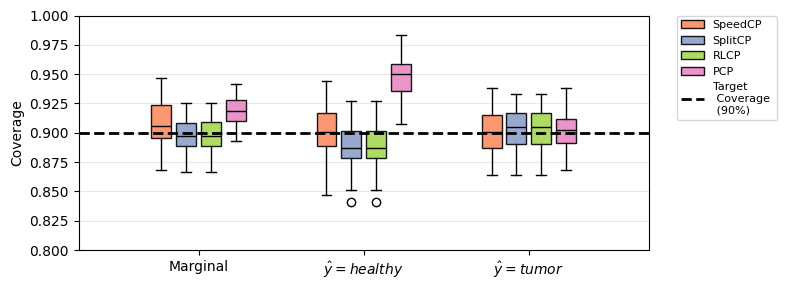


Marginal Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9084, Std=0.0172, Min=0.8683, Max=0.9467, N=50
Split       : Mean=0.8980, Std=0.0142, Min=0.8667, Max=0.9250, N=50
RLCP        : Mean=0.8980, Std=0.0143, Min=0.8667, Max=0.9250, N=50
PCP         : Mean=0.9182, Std=0.0114, Min=0.8933, Max=0.9417, N=50

$\hat y = healthy$ Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9029, Std=0.0223, Min=0.8472, Max=0.9437, N=50
Split       : Mean=0.8888, Std=0.0180, Min=0.8407, Max=0.9269, N=50
RLCP        : Mean=0.8888, Std=0.0180, Min=0.8407, Max=0.9269, N=50
PCP         : Mean=0.9458, Std=0.0193, Min=0.9071, Max=0.9831, N=50

$\hat y = tumor$ Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9016, Std=0.0189, Min=0.8643, Max=0.9385, N=50
Split       : Mean=0.9033, Std=0.0169, Min=0.8641, Max=0.9326, N=50
RL

In [ ]:
# Load the saved results and plot coverage comparison
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the results
output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_predicted_labels_0_False_0', 'all')
output_file = os.path.join(output_dir, "all.npz")

if os.path.exists(output_file):
    results = np.load(output_file, allow_pickle=True)
    
    # Extract runs information
    runs = results["runs"]
    print(runs)
    
    # Define methods and colors
    methods = [ "LAKCP_CV", "Split", "RLCP", "PCP"]
    methods_map = {"LAKCP_CV": "SpeedCP", "Split": "SplitCP", "RLCP": "RLCP", "PCP": "PCP"}

    palette  = {'LAKCP_CV': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
    'Split': (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
    'PCP': (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
    'RLCP': (0.6509803921568628, 0.8470588235294118, 0.32941176470588235)}
    colors = [palette[method] for method in methods]
    

    # Calculate different types of coverage for each method across all runs
    marginal_coverage_data = {method: [] for method in methods}
    conditional_coverage_y0_data = {method: [] for method in methods}
    conditional_coverage_y1_data = {method: [] for method in methods}
    
    for i in runs:
        # Get y_test for this run
        y_test_key = f"predicted_y_test_{i}"
        if y_test_key not in results:
            continue
        y_test = results[y_test_key]
        
        for method in methods:
            covers_key = f"{method}_covers_{i}"
            if covers_key in results:
                covers = results[covers_key]
                
                # Marginal coverage
                marginal_coverage = np.sum(covers) / len(covers)
                #print(f"Marginal coverage for {method} in run {i}: {len:.4f}")
                marginal_coverage_data[method].append(marginal_coverage)
                
                # Conditional coverage for y=0
                mask_y0 = (y_test == 0)
                if np.sum(mask_y0) > 0:
                    covers_y0 = covers[mask_y0]
                    conditional_coverage_y0 = np.sum(covers_y0) / len(covers_y0)
                    conditional_coverage_y0_data[method].append(conditional_coverage_y0)
                
                # Conditional coverage for y=1
                mask_y1 = (y_test == 1)
                if np.sum(mask_y1) > 0:
                    covers_y1 = covers[mask_y1]
                    conditional_coverage_y1 = np.sum(covers_y1) / len(covers_y1)
                    conditional_coverage_y1_data[method].append(conditional_coverage_y1)
    
    # Create single figure with all coverage types
    fig, ax = plt.subplots(1, 1, figsize=(8,3))
    
    coverage_types = ["Marginal", r"$\hat y = healthy$", r"$\hat y = tumor$"]
    coverage_datasets = [marginal_coverage_data, conditional_coverage_y0_data, conditional_coverage_y1_data]
    
    # Calculate positions for box plots
    n_coverage_types = len(coverage_types)
    n_methods = len(methods)
    width = 0.6 / n_methods  # Width of each box
    
    # Create box plots for each method across all coverage types
    for method_idx, (method, color) in enumerate(zip(methods, colors)):
        positions = []
        data_to_plot = []
        
        for coverage_idx, coverage_data in enumerate(coverage_datasets):
            if coverage_data[method]:  # Only include if there's data
                positions.append(coverage_idx + 1 + (method_idx - n_methods/2 + 0.5) * width)
                data_to_plot.append(coverage_data[method])
        
        if data_to_plot:  # Only create plot if there's data
            bp = ax.boxplot(data_to_plot, positions=positions, widths=width*0.8, 
                           patch_artist=True, label=methods_map[method], medianprops=dict(color='black')#,showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red')
                           )
            
            # Color the boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.9)
    
    # Add reference line at 0.9
    ax.axhline(y=0.9, color='black', linestyle='--', linewidth=2, label='Target \n Coverage \n (90%)')
    
    # Customize the plot
    ax.set_ylabel('Coverage', fontsize=10)
    #ax.set_xlabel('Coverage Type', fontsize=14)
   # ax.set_title('Coverage Comparison Across Different Types', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, n_coverage_types + 1))
    ax.set_xticklabels(coverage_types, fontsize=10)
    
    # Set y-axis limits for better visualization
    ax.set_ylim(0.8, 1.0)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics for all coverage types
    for coverage_name, coverage_data in zip(coverage_types, coverage_datasets):
        print(f"\n{coverage_name} Coverage Summary Statistics:")
        print("-" * 60)
        for method in methods:
            if coverage_data[method]:
                coverages = np.array(coverage_data[method])
                print(f"{method:12s}: Mean={coverages.mean():.4f}, Std={coverages.std():.4f}, "
                      f"Min={coverages.min():.4f}, Max={coverages.max():.4f}, N={len(coverages)}")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")



### Use linear component Phi = intercept

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


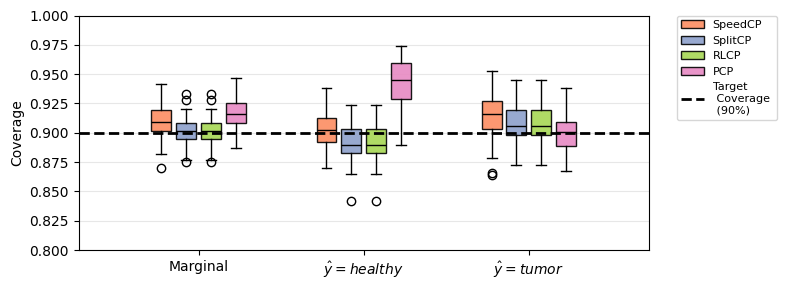


Marginal Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9100, Std=0.0150, Min=0.8700, Max=0.9417, N=50
Split       : Mean=0.9012, Std=0.0123, Min=0.8750, Max=0.9333, N=50
RLCP        : Mean=0.9012, Std=0.0123, Min=0.8750, Max=0.9333, N=50
PCP         : Mean=0.9158, Std=0.0122, Min=0.8867, Max=0.9467, N=50

$\hat y = healthy$ Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9024, Std=0.0169, Min=0.8696, Max=0.9378, N=50
Split       : Mean=0.8909, Std=0.0153, Min=0.8419, Max=0.9234, N=50
RLCP        : Mean=0.8909, Std=0.0153, Min=0.8419, Max=0.9234, N=50
PCP         : Mean=0.9423, Std=0.0189, Min=0.8894, Max=0.9739, N=50

$\hat y = tumor$ Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9146, Std=0.0197, Min=0.8644, Max=0.9530, N=50
Split       : Mean=0.9074, Std=0.0164, Min=0.8723, Max=0.9448, N=50
RL

In [ ]:
# Load the saved results and plot coverage comparison
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the results
output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_intercept_0_False_0', 'all')
output_file = os.path.join(output_dir, "all.npz")

if os.path.exists(output_file):
    results = np.load(output_file, allow_pickle=True)
    
    # Extract runs information
    runs = results["runs"]
    print(runs)
    
    # Define methods and colors
     methods = [ "LAKCP_CV", "Split", "RLCP", "PCP"]
    methods_map = {"LAKCP_CV": "SpeedCP", "Split": "SplitCP", "RLCP": "RLCP", "PCP": "PCP"}
    palette  = {'LAKCP_CV': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
    'Split': (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
    'PCP': (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
    'RLCP': (0.6509803921568628, 0.8470588235294118, 0.32941176470588235)}
    colors = [palette[method] for method in methods]
    

    # Calculate different types of coverage for each method across all runs
    marginal_coverage_data = {method: [] for method in methods}
    conditional_coverage_y0_data = {method: [] for method in methods}
    conditional_coverage_y1_data = {method: [] for method in methods}
    
    for i in runs:
        # Get y_test for this run
        y_test_key = f"predicted_y_test_{i}"
        if y_test_key not in results:
            continue
        y_test = results[y_test_key]
        
        for method in methods:
            covers_key = f"{method}_covers_{i}"
            if covers_key in results:
                covers = results[covers_key]
                
                # Marginal coverage
                marginal_coverage = np.sum(covers) / len(covers)
                #print(f"Marginal coverage for {method} in run {i}: {len:.4f}")
                marginal_coverage_data[method].append(marginal_coverage)
                
                # Conditional coverage for y=0
                mask_y0 = (y_test == 0)
                if np.sum(mask_y0) > 0:
                    covers_y0 = covers[mask_y0]
                    conditional_coverage_y0 = np.sum(covers_y0) / len(covers_y0)
                    conditional_coverage_y0_data[method].append(conditional_coverage_y0)
                
                # Conditional coverage for y=1
                mask_y1 = (y_test == 1)
                if np.sum(mask_y1) > 0:
                    covers_y1 = covers[mask_y1]
                    conditional_coverage_y1 = np.sum(covers_y1) / len(covers_y1)
                    conditional_coverage_y1_data[method].append(conditional_coverage_y1)
    
    # Create single figure with all coverage types
    fig, ax = plt.subplots(1, 1, figsize=(8,3))
    
    coverage_types = ["Marginal", r"$\hat y = healthy$", r"$\hat y = tumor$"]
    coverage_datasets = [marginal_coverage_data, conditional_coverage_y0_data, conditional_coverage_y1_data]
    
    # Calculate positions for box plots
    n_coverage_types = len(coverage_types)
    n_methods = len(methods)
    width = 0.6 / n_methods  # Width of each box
    
    # Create box plots for each method across all coverage types
    for method_idx, (method, color) in enumerate(zip(methods, colors)):
        positions = []
        data_to_plot = []
        
        for coverage_idx, coverage_data in enumerate(coverage_datasets):
            if coverage_data[method]:  # Only include if there's data
                positions.append(coverage_idx + 1 + (method_idx - n_methods/2 + 0.5) * width)
                data_to_plot.append(coverage_data[method])
        
        if data_to_plot:  # Only create plot if there's data
            bp = ax.boxplot(data_to_plot, positions=positions, widths=width*0.8, 
                           patch_artist=True, label=methods_map[method], medianprops=dict(color='black')#,showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red')
                           )
            
            # Color the boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.9)
    
    # Add reference line at 0.9
    ax.axhline(y=0.9, color='black', linestyle='--', linewidth=2, label='Target \n Coverage \n (90%)')
    
    # Customize the plot
    ax.set_ylabel('Coverage', fontsize=10)
    #ax.set_xlabel('Coverage Type', fontsize=14)
   # ax.set_title('Coverage Comparison Across Different Types', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, n_coverage_types + 1))
    ax.set_xticklabels(coverage_types, fontsize=10)
    
    # Set y-axis limits for better visualization
    ax.set_ylim(0.8, 1.0)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics for all coverage types
    for coverage_name, coverage_data in zip(coverage_types, coverage_datasets):
        print(f"\n{coverage_name} Coverage Summary Statistics:")
        print("-" * 60)
        for method in methods:
            if coverage_data[method]:
                coverages = np.array(coverage_data[method])
                print(f"{method:12s}: Mean={coverages.mean():.4f}, Std={coverages.std():.4f}, "
                      f"Min={coverages.min():.4f}, Max={coverages.max():.4f}, N={len(coverages)}")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")



#### Prediction set size (Phi = predicted labels / intercept)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


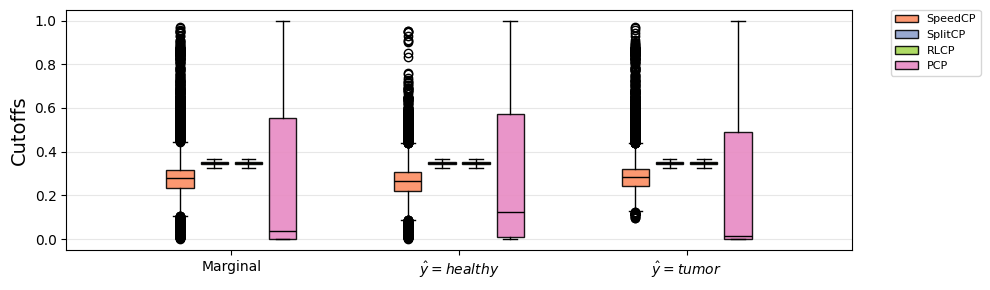


Marginal Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2828, Std=0.0820, Min=0.0025, Max=0.9714, N=30000
Split       : Mean=0.3482, Std=0.0091, Min=0.3271, Max=0.3660, N=30000
RLCP        : Mean=0.3482, Std=0.0091, Min=0.3271, Max=0.3660, N=30000
PCP         : Mean=0.2310, Std=0.2899, Min=0.0000, Max=0.9984, N=30000

$\hat y = healthy$ Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2662, Std=0.0819, Min=0.0025, Max=0.9533, N=11098
Split       : Mean=0.3482, Std=0.0091, Min=0.3271, Max=0.3660, N=11098
RLCP        : Mean=0.3482, Std=0.0091, Min=0.3271, Max=0.3660, N=11098
PCP         : Mean=0.2818, Std=0.2904, Min=0.0000, Max=0.9984, N=11098

$\hat y = tumor$ Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2925, Std=0.0805, Min=0.0952, Max=0.9714, N=18902
Split       : Mean=0.3482, Std=0.0091, Min=0.3

In [ ]:
# Load the saved results and plot coverage comparison
import numpy as np
import matplotlib.pyplot as plt
import os

output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_predicted_labels_0_False_0', 'all')
output_file = os.path.join(output_dir, "all.npz")

if os.path.exists(output_file):
    results = np.load(output_file, allow_pickle=True)
    
    # Extract runs information
    runs = results["runs"]
    print(runs)
    
    # Calculate different types of coverage for each method across all runs
    marginal_coverage_data = {method: [] for method in methods}
    conditional_coverage_y0_data = {method: [] for method in methods}
    conditional_coverage_y1_data = {method: [] for method in methods}
    
    for r in runs:
        # Get y_test for this run
        y_test_key = f"predicted_y_test_{r}"
        if y_test_key not in results:
            continue
        y_test = results[y_test_key]
        
        for method in methods:
            covers_key = f"{method}_cutoffs_{r}"
            if covers_key in results:
                covers = results[covers_key]
                
                # Marginal coverage
                marginal_coverage = covers
                #print(f"Marginal coverage for {method} in run {i}: {len(marginal_coverage)}")
                #print(f"Marginal coverage for {method} in run {i}: {len:.4f}")
                for i in range(len(marginal_coverage)):
                    marginal_coverage_data[method].append(marginal_coverage[i])
                
                # Conditional coverage for y=0
                mask_y0 = (y_test == 0)
                if np.sum(mask_y0) > 0:
                    covers_y0 = covers[mask_y0]
                    conditional_coverage_y0 = covers_y0
                    for i in range(len(conditional_coverage_y0)):
                        conditional_coverage_y0_data[method].append(conditional_coverage_y0[i])
                # Conditional coverage for y=1
                mask_y1 = (y_test == 1)
                if np.sum(mask_y1) > 0:
                    covers_y1 = covers[mask_y1]
                    conditional_coverage_y1 = covers_y1
                    for i in range(len(conditional_coverage_y1)):
                        conditional_coverage_y1_data[method].append(conditional_coverage_y1[i])
    # Create single figure with all coverage types
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    
   # coverage_types = ["Marginal", r"Conditional ($\hat Y=0$)", r"Conditional ($\hat Y=1$)"]
    coverage_datasets = [marginal_coverage_data, conditional_coverage_y0_data, conditional_coverage_y1_data]
    
    # Calculate positions for box plots
    n_coverage_types = len(coverage_types)
    n_methods = len(methods)
    #width = 0.8 / n_methods  # Width of each box
    
    # Create box plots for each method across all coverage types
    for method_idx, (method, color) in enumerate(zip(methods, colors)):
        positions = []
        data_to_plot = []
        
        for coverage_idx, coverage_data in enumerate(coverage_datasets):
            if coverage_data[method]:  # Only include if there's data
                positions.append(coverage_idx + 1 + (method_idx - n_methods/2 + 0.5) * width)
                data_to_plot.append(coverage_data[method])
        
        if data_to_plot:  # Only create plot if there's data
            bp = ax.boxplot(data_to_plot, positions=positions, widths=width*0.8, 
                           patch_artist=True, label=methods_map[method], medianprops=dict(color='black')#,showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red')
                           )
            
            # Color the boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.9)
    
    # Add reference line at 0.9
    #ax.axhline(y=0.9, color='black', linestyle='--', linewidth=2, label='Target Coverage (90%)')
    
    # Customize the plot
    ax.set_ylabel('Cutoffs', fontsize=14)
    #ax.set_xlabel('Coverage Type', fontsize=14)
    #ax.set_title('Cutoffs Comparison Across Different Types', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, n_coverage_types + 1))
    ax.set_xticklabels(coverage_types, fontsize=10)
    
    # Set y-axis limits for better visualization
    #ax.set_ylim(-0.1, 1.1)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics for all coverage types
    for coverage_name, coverage_data in zip(coverage_types, coverage_datasets):
        print(f"\n{coverage_name} Cutoffs Summary Statistics:")
        print("-" * 60)
        for method in methods:
            if coverage_data[method]:
                coverages = np.array(coverage_data[method])
                print(f"{method:12s}: Mean={coverages.mean():.4f}, Std={coverages.std():.4f}, "
                      f"Min={coverages.min():.4f}, Max={coverages.max():.4f}, N={len(coverages)}")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")



[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


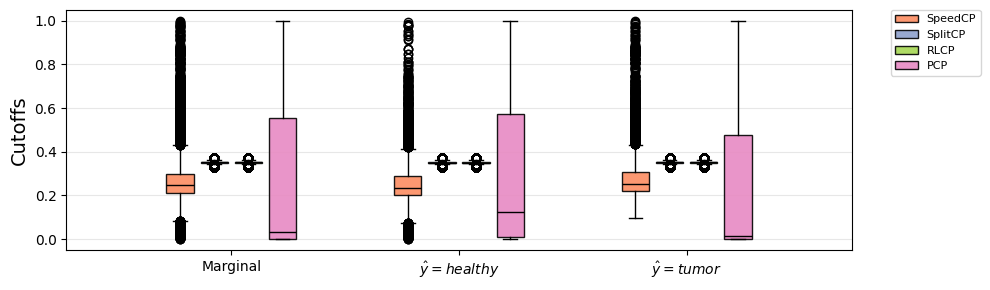


Marginal Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2662, Std=0.0908, Min=0.0012, Max=0.9985, N=30000
Split       : Mean=0.3504, Std=0.0080, Min=0.3307, Max=0.3729, N=30000
RLCP        : Mean=0.3504, Std=0.0080, Min=0.3307, Max=0.3729, N=30000
PCP         : Mean=0.2275, Std=0.2871, Min=0.0000, Max=0.9984, N=30000

$\hat y = healthy$ Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2500, Std=0.0954, Min=0.0012, Max=0.9938, N=11141
Split       : Mean=0.3505, Std=0.0080, Min=0.3307, Max=0.3729, N=11141
RLCP        : Mean=0.3505, Std=0.0080, Min=0.3307, Max=0.3729, N=11141
PCP         : Mean=0.2770, Std=0.2902, Min=0.0000, Max=0.9984, N=11141

$\hat y = tumor$ Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2758, Std=0.0866, Min=0.0963, Max=0.9985, N=18859
Split       : Mean=0.3504, Std=0.0080, Min=0.3

In [ ]:
# Load the saved results and plot coverage comparison
import numpy as np
import matplotlib.pyplot as plt
import os

output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_intercept_0_False_0', 'all')
output_file = os.path.join(output_dir, "all.npz")

if os.path.exists(output_file):
    results = np.load(output_file, allow_pickle=True)
    
    # Extract runs information
    runs = results["runs"]
    print(runs)
    
    # Calculate different types of coverage for each method across all runs
    marginal_coverage_data = {method: [] for method in methods}
    conditional_coverage_y0_data = {method: [] for method in methods}
    conditional_coverage_y1_data = {method: [] for method in methods}
    
    for r in runs:
        # Get y_test for this run
        y_test_key = f"predicted_y_test_{r}"
        if y_test_key not in results:
            continue
        y_test = results[y_test_key]
        
        for method in methods:
            covers_key = f"{method}_cutoffs_{r}"
            if covers_key in results:
                covers = results[covers_key]
                
                # Marginal coverage
                marginal_coverage = covers
                #print(f"Marginal coverage for {method} in run {i}: {len(marginal_coverage)}")
                #print(f"Marginal coverage for {method} in run {i}: {len:.4f}")
                for i in range(len(marginal_coverage)):
                    marginal_coverage_data[method].append(marginal_coverage[i])
                
                # Conditional coverage for y=0
                mask_y0 = (y_test == 0)
                if np.sum(mask_y0) > 0:
                    covers_y0 = covers[mask_y0]
                    conditional_coverage_y0 = covers_y0
                    for i in range(len(conditional_coverage_y0)):
                        conditional_coverage_y0_data[method].append(conditional_coverage_y0[i])
                # Conditional coverage for y=1
                mask_y1 = (y_test == 1)
                if np.sum(mask_y1) > 0:
                    covers_y1 = covers[mask_y1]
                    conditional_coverage_y1 = covers_y1
                    for i in range(len(conditional_coverage_y1)):
                        conditional_coverage_y1_data[method].append(conditional_coverage_y1[i])
    # Create single figure with all coverage types
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    
   # coverage_types = ["Marginal", r"Conditional ($\hat Y=0$)", r"Conditional ($\hat Y=1$)"]
    coverage_datasets = [marginal_coverage_data, conditional_coverage_y0_data, conditional_coverage_y1_data]
    
    # Calculate positions for box plots
    n_coverage_types = len(coverage_types)
    n_methods = len(methods)
    #width = 0.8 / n_methods  # Width of each box
    
    # Create box plots for each method across all coverage types
    for method_idx, (method, color) in enumerate(zip(methods, colors)):
        positions = []
        data_to_plot = []
        
        for coverage_idx, coverage_data in enumerate(coverage_datasets):
            if coverage_data[method]:  # Only include if there's data
                positions.append(coverage_idx + 1 + (method_idx - n_methods/2 + 0.5) * width)
                data_to_plot.append(coverage_data[method])
        
        if data_to_plot:  # Only create plot if there's data
            bp = ax.boxplot(data_to_plot, positions=positions, widths=width*0.8, 
                           patch_artist=True, label=methods_map[method], medianprops=dict(color='black')#,showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red')
                           )
            
            # Color the boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.9)
    
    # Add reference line at 0.9
    #ax.axhline(y=0.9, color='black', linestyle='--', linewidth=2, label='Target Coverage (90%)')
    
    # Customize the plot
    ax.set_ylabel('Cutoffs', fontsize=14)
    #ax.set_xlabel('Coverage Type', fontsize=14)
    #ax.set_title('Cutoffs Comparison Across Different Types', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, n_coverage_types + 1))
    ax.set_xticklabels(coverage_types, fontsize=10)
    
    # Set y-axis limits for better visualization
    #ax.set_ylim(-0.1, 1.1)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics for all coverage types
    for coverage_name, coverage_data in zip(coverage_types, coverage_datasets):
        print(f"\n{coverage_name} Cutoffs Summary Statistics:")
        print("-" * 60)
        for method in methods:
            if coverage_data[method]:
                coverages = np.array(coverage_data[method])
                print(f"{method:12s}: Mean={coverages.mean():.4f}, Std={coverages.std():.4f}, "
                      f"Min={coverages.min():.4f}, Max={coverages.max():.4f}, N={len(coverages)}")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")



## Conformal Prediction using PCA on the feature layer from NN

### Use linear component Phi = predicted labels

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


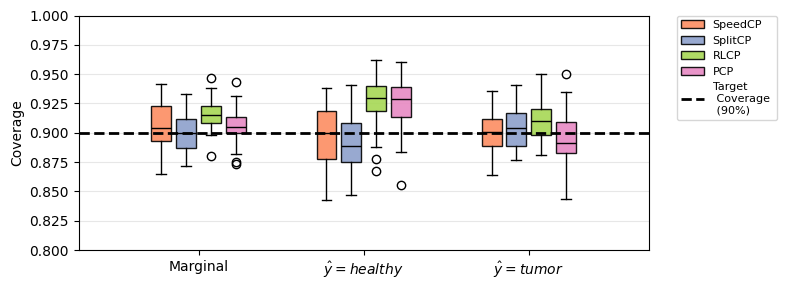


Marginal Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9057, Std=0.0177, Min=0.8650, Max=0.9417, N=50
Split       : Mean=0.8994, Std=0.0154, Min=0.8717, Max=0.9333, N=50
RLCP        : Mean=0.9156, Std=0.0119, Min=0.8800, Max=0.9467, N=50
PCP         : Mean=0.9058, Std=0.0139, Min=0.8733, Max=0.9433, N=50

$\hat y = healthy$ Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.8979, Std=0.0259, Min=0.8426, Max=0.9381, N=50
Split       : Mean=0.8918, Std=0.0228, Min=0.8468, Max=0.9404, N=50
RLCP        : Mean=0.9262, Std=0.0188, Min=0.8673, Max=0.9623, N=50
PCP         : Mean=0.9255, Std=0.0213, Min=0.8553, Max=0.9602, N=50

$\hat y = tumor$ Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9004, Std=0.0178, Min=0.8644, Max=0.9357, N=50
Split       : Mean=0.9039, Std=0.0161, Min=0.8770, Max=0.9407, N=50
RL

In [ ]:
# Load the saved results and plot coverage comparison
import numpy as np
import matplotlib.pyplot as plt
import os


# Load the results
output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_predicted_labels_0_True_8', 'all')
output_file = os.path.join(output_dir, "all.npz")

if os.path.exists(output_file):
    results = np.load(output_file, allow_pickle=True)
    
    # Extract runs information
    runs = results["runs"]
    print(runs)
    
    # Define methods and colors
    methods = [ "LAKCP_CV", "Split", "RLCP", "PCP"]
    methods_map = {"LAKCP_CV": "SpeedCP", "Split": "SplitCP", "RLCP": "RLCP", "PCP": "PCP"}
    palette  = {'LAKCP_CV': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
    'Split': (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
    'PCP': (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
    'RLCP': (0.6509803921568628, 0.8470588235294118, 0.32941176470588235)}
    colors = [palette[method] for method in methods]
    

    # Calculate different types of coverage for each method across all runs
    marginal_coverage_data = {method: [] for method in methods}
    conditional_coverage_y0_data = {method: [] for method in methods}
    conditional_coverage_y1_data = {method: [] for method in methods}
    
    for i in runs:
        # Get y_test for this run
        y_test_key = f"predicted_y_test_{i}"
        if y_test_key not in results:
            continue
        y_test = results[y_test_key]
        
        for method in methods:
            covers_key = f"{method}_covers_{i}"
            if covers_key in results:
                covers = results[covers_key]
                
                # Marginal coverage
                marginal_coverage = np.sum(covers) / len(covers)
                #print(f"Marginal coverage for {method} in run {i}: {len:.4f}")
                marginal_coverage_data[method].append(marginal_coverage)
                
                # Conditional coverage for y=0
                mask_y0 = (y_test == 0)
                if np.sum(mask_y0) > 0:
                    covers_y0 = covers[mask_y0]
                    conditional_coverage_y0 = np.sum(covers_y0) / len(covers_y0)
                    conditional_coverage_y0_data[method].append(conditional_coverage_y0)
                
                # Conditional coverage for y=1
                mask_y1 = (y_test == 1)
                if np.sum(mask_y1) > 0:
                    covers_y1 = covers[mask_y1]
                    conditional_coverage_y1 = np.sum(covers_y1) / len(covers_y1)
                    conditional_coverage_y1_data[method].append(conditional_coverage_y1)
    
    # Create single figure with all coverage types
    fig, ax = plt.subplots(1, 1, figsize=(8,3))
    
    coverage_types = ["Marginal", r"$\hat y = healthy$", r"$\hat y = tumor$"]
    coverage_datasets = [marginal_coverage_data, conditional_coverage_y0_data, conditional_coverage_y1_data]
    
    # Calculate positions for box plots
    n_coverage_types = len(coverage_types)
    n_methods = len(methods)
    width = 0.6 / n_methods  # Width of each box
    
    # Create box plots for each method across all coverage types
    for method_idx, (method, color) in enumerate(zip(methods, colors)):
        positions = []
        data_to_plot = []
        
        for coverage_idx, coverage_data in enumerate(coverage_datasets):
            if coverage_data[method]:  # Only include if there's data
                positions.append(coverage_idx + 1 + (method_idx - n_methods/2 + 0.5) * width)
                data_to_plot.append(coverage_data[method])
        
        if data_to_plot:  # Only create plot if there's data
            bp = ax.boxplot(data_to_plot, positions=positions, widths=width*0.8, 
                           patch_artist=True, label=methods_map[method], medianprops=dict(color='black')#,showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red')
                           )
            
            # Color the boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.9)
    
    # Add reference line at 0.9
    ax.axhline(y=0.9, color='black', linestyle='--', linewidth=2, label='Target \n Coverage \n (90%)')
    
    # Customize the plot
    ax.set_ylabel('Coverage', fontsize=10)
    #ax.set_xlabel('Coverage Type', fontsize=14)
   # ax.set_title('Coverage Comparison Across Different Types', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, n_coverage_types + 1))
    ax.set_xticklabels(coverage_types, fontsize=10)
    
    # Set y-axis limits for better visualization
    ax.set_ylim(0.8, 1.0)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics for all coverage types
    for coverage_name, coverage_data in zip(coverage_types, coverage_datasets):
        print(f"\n{coverage_name} Coverage Summary Statistics:")
        print("-" * 60)
        for method in methods:
            if coverage_data[method]:
                coverages = np.array(coverage_data[method])
                print(f"{method:12s}: Mean={coverages.mean():.4f}, Std={coverages.std():.4f}, "
                      f"Min={coverages.min():.4f}, Max={coverages.max():.4f}, N={len(coverages)}")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")



### Use linear component Phi = intercept

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


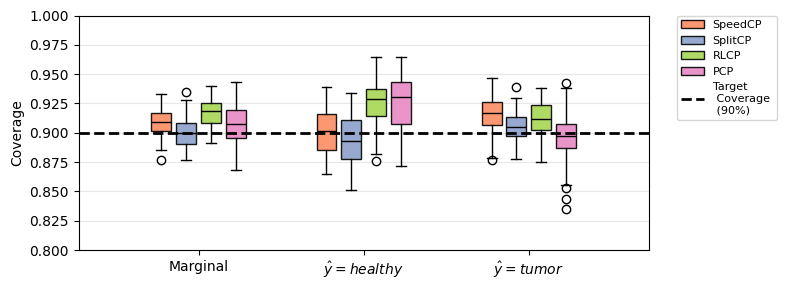


Marginal Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9102, Std=0.0124, Min=0.8767, Max=0.9333, N=50
Split       : Mean=0.9010, Std=0.0132, Min=0.8767, Max=0.9350, N=50
RLCP        : Mean=0.9162, Std=0.0111, Min=0.8917, Max=0.9400, N=50
PCP         : Mean=0.9064, Std=0.0162, Min=0.8683, Max=0.9433, N=50

$\hat y = healthy$ Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9018, Std=0.0196, Min=0.8652, Max=0.9387, N=50
Split       : Mean=0.8932, Std=0.0217, Min=0.8514, Max=0.9336, N=50
RLCP        : Mean=0.9257, Std=0.0187, Min=0.8761, Max=0.9646, N=50
PCP         : Mean=0.9245, Std=0.0234, Min=0.8717, Max=0.9644, N=50

$\hat y = tumor$ Coverage Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.9154, Std=0.0145, Min=0.8766, Max=0.9471, N=50
Split       : Mean=0.9057, Std=0.0132, Min=0.8779, Max=0.9387, N=50
RL

In [ ]:
# Load the saved results and plot coverage comparison
import numpy as np
import matplotlib.pyplot as plt
import os

# I used used_2
# Load the results
output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_intercept_0_True_8', 'all')
output_file = os.path.join(output_dir, "all.npz")

if os.path.exists(output_file):
    results = np.load(output_file, allow_pickle=True)
    
    # Extract runs information
    runs = results["runs"]
    print(runs)
    
    # Define methods and colors
    methods = [ "LAKCP_CV", "Split", "RLCP", "PCP"]
    methods_map = {"LAKCP_CV": "SpeedCP", "Split": "SplitCP", "RLCP": "RLCP", "PCP": "PCP"}
    palette  = {'LAKCP_CV': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
    'Split': (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
    'PCP': (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
    'RLCP': (0.6509803921568628, 0.8470588235294118, 0.32941176470588235)}
    colors = [palette[method] for method in methods]
    

    # Calculate different types of coverage for each method across all runs
    marginal_coverage_data = {method: [] for method in methods}
    conditional_coverage_y0_data = {method: [] for method in methods}
    conditional_coverage_y1_data = {method: [] for method in methods}
    
    for i in runs:
        # Get y_test for this run
        y_test_key = f"predicted_y_test_{i}"
        if y_test_key not in results:
            continue
        y_test = results[y_test_key]
        
        for method in methods:
            covers_key = f"{method}_covers_{i}"
            if covers_key in results:
                covers = results[covers_key]
                
                # Marginal coverage
                marginal_coverage = np.sum(covers) / len(covers)
                #print(f"Marginal coverage for {method} in run {i}: {len:.4f}")
                marginal_coverage_data[method].append(marginal_coverage)
                
                # Conditional coverage for y=0
                mask_y0 = (y_test == 0)
                if np.sum(mask_y0) > 0:
                    covers_y0 = covers[mask_y0]
                    conditional_coverage_y0 = np.sum(covers_y0) / len(covers_y0)
                    conditional_coverage_y0_data[method].append(conditional_coverage_y0)
                
                # Conditional coverage for y=1
                mask_y1 = (y_test == 1)
                if np.sum(mask_y1) > 0:
                    covers_y1 = covers[mask_y1]
                    conditional_coverage_y1 = np.sum(covers_y1) / len(covers_y1)
                    conditional_coverage_y1_data[method].append(conditional_coverage_y1)
    
    # Create single figure with all coverage types
    fig, ax = plt.subplots(1, 1, figsize=(8,3))
    
    coverage_types = ["Marginal", r"$\hat y = healthy$", r"$\hat y = tumor$"]
    coverage_datasets = [marginal_coverage_data, conditional_coverage_y0_data, conditional_coverage_y1_data]
    
    # Calculate positions for box plots
    n_coverage_types = len(coverage_types)
    n_methods = len(methods)
    width = 0.6 / n_methods  # Width of each box
    
    # Create box plots for each method across all coverage types
    for method_idx, (method, color) in enumerate(zip(methods, colors)):
        positions = []
        data_to_plot = []
        
        for coverage_idx, coverage_data in enumerate(coverage_datasets):
            if coverage_data[method]:  # Only include if there's data
                positions.append(coverage_idx + 1 + (method_idx - n_methods/2 + 0.5) * width)
                data_to_plot.append(coverage_data[method])
        
        if data_to_plot:  # Only create plot if there's data
            bp = ax.boxplot(data_to_plot, positions=positions, widths=width*0.8, 
                           patch_artist=True, label=methods_map[method], medianprops=dict(color='black')#,showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red')
                           )
            
            # Color the boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.9)
    
    # Add reference line at 0.9
    ax.axhline(y=0.9, color='black', linestyle='--', linewidth=2, label='Target \n Coverage \n (90%)')
    
    # Customize the plot
    ax.set_ylabel('Coverage', fontsize=10)
    #ax.set_xlabel('Coverage Type', fontsize=14)
   # ax.set_title('Coverage Comparison Across Different Types', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, n_coverage_types + 1))
    ax.set_xticklabels(coverage_types, fontsize=10)
    
    # Set y-axis limits for better visualization
    ax.set_ylim(0.8, 1.0)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics for all coverage types
    for coverage_name, coverage_data in zip(coverage_types, coverage_datasets):
        print(f"\n{coverage_name} Coverage Summary Statistics:")
        print("-" * 60)
        for method in methods:
            if coverage_data[method]:
                coverages = np.array(coverage_data[method])
                print(f"{method:12s}: Mean={coverages.mean():.4f}, Std={coverages.std():.4f}, "
                      f"Min={coverages.min():.4f}, Max={coverages.max():.4f}, N={len(coverages)}")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")



#### Prediction set size (Phi = predicted labels / intercept)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


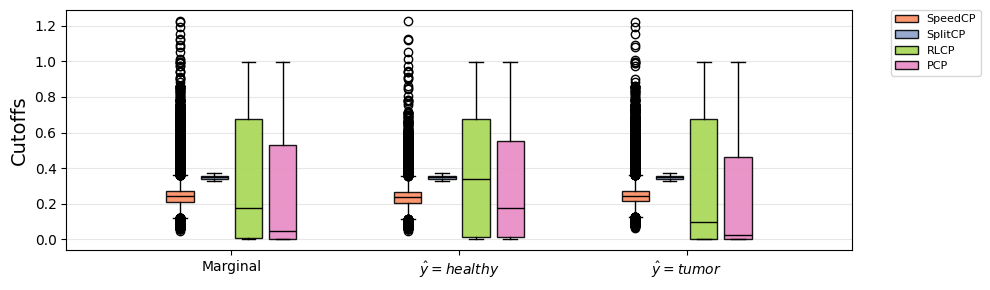


Marginal Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2470, Std=0.0805, Min=0.0442, Max=1.2279, N=30000
Split       : Mean=0.3491, Std=0.0102, Min=0.3287, Max=0.3729, N=30000
RLCP        : Mean=0.3635, Std=0.3818, Min=0.0000, Max=0.9984, N=30000
PCP         : Mean=0.2265, Std=0.2678, Min=0.0000, Max=0.9984, N=30000

$\hat y = healthy$ Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2409, Std=0.0785, Min=0.0442, Max=1.2279, N=11129
Split       : Mean=0.3491, Std=0.0103, Min=0.3287, Max=0.3729, N=11129
RLCP        : Mean=0.3990, Std=0.3771, Min=0.0000, Max=0.9984, N=11129
PCP         : Mean=0.2717, Std=0.2668, Min=0.0000, Max=0.9984, N=11129

$\hat y = tumor$ Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2506, Std=0.0815, Min=0.0615, Max=1.2225, N=18871
Split       : Mean=0.3491, Std=0.0102, Min=0.3

In [ ]:
# Load the saved results and plot coverage comparison
import numpy as np
import matplotlib.pyplot as plt
import os

output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_predicted_labels_0_True_8', 'all')
output_file = os.path.join(output_dir, "all.npz")

if os.path.exists(output_file):
    results = np.load(output_file, allow_pickle=True)
    
    # Extract runs information
    runs = results["runs"]
    print(runs)
    
    # Calculate different types of coverage for each method across all runs
    marginal_coverage_data = {method: [] for method in methods}
    conditional_coverage_y0_data = {method: [] for method in methods}
    conditional_coverage_y1_data = {method: [] for method in methods}
    
    for r in runs:
        # Get y_test for this run
        y_test_key = f"predicted_y_test_{r}"
        if y_test_key not in results:
            continue
        y_test = results[y_test_key]
        
        for method in methods:
            covers_key = f"{method}_cutoffs_{r}"
            if covers_key in results:
                covers = results[covers_key]
                
                # Marginal coverage
                marginal_coverage = covers
                #print(f"Marginal coverage for {method} in run {i}: {len(marginal_coverage)}")
                #print(f"Marginal coverage for {method} in run {i}: {len:.4f}")
                for i in range(len(marginal_coverage)):
                    marginal_coverage_data[method].append(marginal_coverage[i])
                
                # Conditional coverage for y=0
                mask_y0 = (y_test == 0)
                if np.sum(mask_y0) > 0:
                    covers_y0 = covers[mask_y0]
                    conditional_coverage_y0 = covers_y0
                    for i in range(len(conditional_coverage_y0)):
                        conditional_coverage_y0_data[method].append(conditional_coverage_y0[i])
                # Conditional coverage for y=1
                mask_y1 = (y_test == 1)
                if np.sum(mask_y1) > 0:
                    covers_y1 = covers[mask_y1]
                    conditional_coverage_y1 = covers_y1
                    for i in range(len(conditional_coverage_y1)):
                        conditional_coverage_y1_data[method].append(conditional_coverage_y1[i])
    # Create single figure with all coverage types
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    
   # coverage_types = ["Marginal", r"Conditional ($\hat Y=0$)", r"Conditional ($\hat Y=1$)"]
    coverage_datasets = [marginal_coverage_data, conditional_coverage_y0_data, conditional_coverage_y1_data]
    
    # Calculate positions for box plots
    n_coverage_types = len(coverage_types)
    n_methods = len(methods)
    #width = 0.8 / n_methods  # Width of each box
    
    # Create box plots for each method across all coverage types
    for method_idx, (method, color) in enumerate(zip(methods, colors)):
        positions = []
        data_to_plot = []
        
        for coverage_idx, coverage_data in enumerate(coverage_datasets):
            if coverage_data[method]:  # Only include if there's data
                positions.append(coverage_idx + 1 + (method_idx - n_methods/2 + 0.5) * width)
                data_to_plot.append(coverage_data[method])
        
        if data_to_plot:  # Only create plot if there's data
            bp = ax.boxplot(data_to_plot, positions=positions, widths=width*0.8, 
                           patch_artist=True, label=methods_map[method], medianprops=dict(color='black')#,showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red')
                           )
            
            # Color the boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.9)
    
    # Add reference line at 0.9
    #ax.axhline(y=0.9, color='black', linestyle='--', linewidth=2, label='Target Coverage (90%)')
    
    # Customize the plot
    ax.set_ylabel('Cutoffs', fontsize=14)
    #ax.set_xlabel('Coverage Type', fontsize=14)
    #ax.set_title('Cutoffs Comparison Across Different Types', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, n_coverage_types + 1))
    ax.set_xticklabels(coverage_types, fontsize=10)
    
    # Set y-axis limits for better visualization
    #ax.set_ylim(-0.1, 1.1)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics for all coverage types
    for coverage_name, coverage_data in zip(coverage_types, coverage_datasets):
        print(f"\n{coverage_name} Cutoffs Summary Statistics:")
        print("-" * 60)
        for method in methods:
            if coverage_data[method]:
                coverages = np.array(coverage_data[method])
                print(f"{method:12s}: Mean={coverages.mean():.4f}, Std={coverages.std():.4f}, "
                      f"Min={coverages.min():.4f}, Max={coverages.max():.4f}, N={len(coverages)}")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")



[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


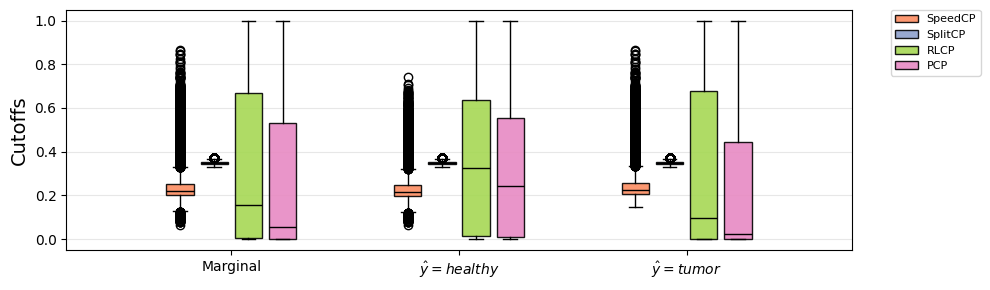


Marginal Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2391, Std=0.0738, Min=0.0654, Max=0.8641, N=30000
Split       : Mean=0.3505, Std=0.0087, Min=0.3315, Max=0.3729, N=30000
RLCP        : Mean=0.3594, Std=0.3797, Min=0.0000, Max=0.9984, N=30000
PCP         : Mean=0.2301, Std=0.2672, Min=0.0000, Max=0.9984, N=30000

$\hat y = healthy$ Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2300, Std=0.0697, Min=0.0654, Max=0.7414, N=11271
Split       : Mean=0.3506, Std=0.0088, Min=0.3315, Max=0.3729, N=11271
RLCP        : Mean=0.3883, Std=0.3711, Min=0.0000, Max=0.9984, N=11271
PCP         : Mean=0.2788, Std=0.2654, Min=0.0000, Max=0.9984, N=11271

$\hat y = tumor$ Cutoffs Summary Statistics:
------------------------------------------------------------
LAKCP_CV    : Mean=0.2445, Std=0.0756, Min=0.1486, Max=0.8641, N=18729
Split       : Mean=0.3505, Std=0.0087, Min=0.3

In [ ]:
# Load the saved results and plot coverage comparison
import numpy as np
import matplotlib.pyplot as plt
import os

output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_intercept_0_True_8', 'all')
output_file = os.path.join(output_dir, "all.npz")

if os.path.exists(output_file):
    results = np.load(output_file, allow_pickle=True)
    
    # Extract runs information
    runs = results["runs"]
    print(runs)
    
    # Calculate different types of coverage for each method across all runs
    marginal_coverage_data = {method: [] for method in methods}
    conditional_coverage_y0_data = {method: [] for method in methods}
    conditional_coverage_y1_data = {method: [] for method in methods}
    
    for r in runs:
        # Get y_test for this run
        y_test_key = f"predicted_y_test_{r}"
        if y_test_key not in results:
            continue
        y_test = results[y_test_key]
        
        for method in methods:
            covers_key = f"{method}_cutoffs_{r}"
            if covers_key in results:
                covers = results[covers_key]
                
                # Marginal coverage
                marginal_coverage = covers
                #print(f"Marginal coverage for {method} in run {i}: {len(marginal_coverage)}")
                #print(f"Marginal coverage for {method} in run {i}: {len:.4f}")
                for i in range(len(marginal_coverage)):
                    marginal_coverage_data[method].append(marginal_coverage[i])
                
                # Conditional coverage for y=0
                mask_y0 = (y_test == 0)
                if np.sum(mask_y0) > 0:
                    covers_y0 = covers[mask_y0]
                    conditional_coverage_y0 = covers_y0
                    for i in range(len(conditional_coverage_y0)):
                        conditional_coverage_y0_data[method].append(conditional_coverage_y0[i])
                # Conditional coverage for y=1
                mask_y1 = (y_test == 1)
                if np.sum(mask_y1) > 0:
                    covers_y1 = covers[mask_y1]
                    conditional_coverage_y1 = covers_y1
                    for i in range(len(conditional_coverage_y1)):
                        conditional_coverage_y1_data[method].append(conditional_coverage_y1[i])
    # Create single figure with all coverage types
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    
   # coverage_types = ["Marginal", r"Conditional ($\hat Y=0$)", r"Conditional ($\hat Y=1$)"]
    coverage_datasets = [marginal_coverage_data, conditional_coverage_y0_data, conditional_coverage_y1_data]
    
    # Calculate positions for box plots
    n_coverage_types = len(coverage_types)
    n_methods = len(methods)
    #width = 0.8 / n_methods  # Width of each box
    
    # Create box plots for each method across all coverage types
    for method_idx, (method, color) in enumerate(zip(methods, colors)):
        positions = []
        data_to_plot = []
        
        for coverage_idx, coverage_data in enumerate(coverage_datasets):
            if coverage_data[method]:  # Only include if there's data
                positions.append(coverage_idx + 1 + (method_idx - n_methods/2 + 0.5) * width)
                data_to_plot.append(coverage_data[method])
        
        if data_to_plot:  # Only create plot if there's data
            bp = ax.boxplot(data_to_plot, positions=positions, widths=width*0.8, 
                           patch_artist=True, label=methods_map[method], medianprops=dict(color='black')#,showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red')
                           )
            
            # Color the boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.9)
    
    # Add reference line at 0.9
    #ax.axhline(y=0.9, color='black', linestyle='--', linewidth=2, label='Target Coverage (90%)')
    
    # Customize the plot
    ax.set_ylabel('Cutoffs', fontsize=14)
    #ax.set_xlabel('Coverage Type', fontsize=14)
    #ax.set_title('Cutoffs Comparison Across Different Types', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Set x-axis ticks and labels
    ax.set_xticks(range(1, n_coverage_types + 1))
    ax.set_xticklabels(coverage_types, fontsize=10)
    
    # Set y-axis limits for better visualization
    #ax.set_ylim(-0.1, 1.1)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics for all coverage types
    for coverage_name, coverage_data in zip(coverage_types, coverage_datasets):
        print(f"\n{coverage_name} Cutoffs Summary Statistics:")
        print("-" * 60)
        for method in methods:
            if coverage_data[method]:
                coverages = np.array(coverage_data[method])
                print(f"{method:12s}: Mean={coverages.mean():.4f}, Std={coverages.std():.4f}, "
                      f"Min={coverages.min():.4f}, Max={coverages.max():.4f}, N={len(coverages)}")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")



## Computation time

RUNNING TIME ANALYSIS


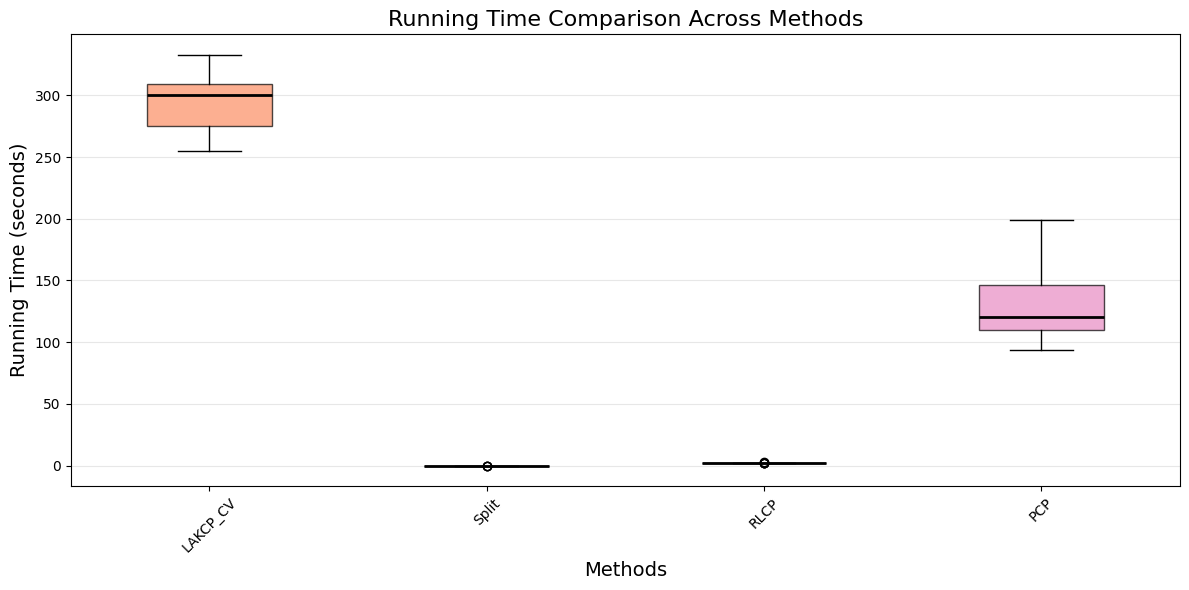


Running Time Summary Statistics:
--------------------------------------------------------------------------------
Method          Mean       Std        Min        Max        Median     N    
--------------------------------------------------------------------------------
LAKCP_CV        294.5618   20.9584    254.8878   332.8104   300.3906   50   
Split           0.0003     0.0000     0.0002     0.0003     0.0003     50   
RLCP            2.0506     0.1198     1.9763     2.7268     2.0129     50   
PCP             131.0962   28.2211    93.8650    199.1108   120.7138   50   

Relative Performance (compared to fastest method):
------------------------------------------------------------
Baseline (fastest): Split with 0.0003 seconds
------------------------------------------------------------
Split          : 1.00  x slower (0.0003s)
RLCP           : 7729.66x slower (2.0506s)
PCP            : 494173.72x slower (131.0962s)
LAKCP_CV       : 1110365.86x slower (294.5618s)

Statistical Signif

In [ ]:
# Running Time Analysis
print("=" * 80)
print("RUNNING TIME ANALYSIS")
print("=" * 80)
output_dir = os.path.join(parent_dir, "results", "real_data", "mri", 'vanilla_predicted_labels_0_True_8', 'all')
output_file = os.path.join(output_dir, "all.npz")
if os.path.exists(output_file):
    data = np.load(output_file)
    
    # Extract running times for each method
    methods = ["LAKCP_CV", "Split", "RLCP", "PCP"]
    time_data = {method: [] for method in methods}
    
    # Get the number of runs
    runs = data.get('runs', [])
    n_runs = len(runs) if len(runs) > 0 else 50
    
    # Extract time data for each method and run
    for i in range(n_runs):
        for method in methods:
            time_key = f"{method}_time_{i}"
            if time_key in data:
                time_value = data[time_key]
                time_data[method].append(float(time_value))
    
    # Create visualization for running times
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Prepare data for boxplot
    methods_with_data = []
    time_values = []

    for i, method in enumerate(methods):
        if time_data[method]:
            methods_with_data.append(method)
            time_values.append(time_data[method])
    
    # Create boxplot
    if time_values:
        bp = ax.boxplot(time_values, labels=methods_with_data, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2))
        
        # Color the boxes
        for patch, color in zip(bp['boxes'], colors[:len(methods_with_data)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
    
    ax.set_ylabel('Running Time (seconds)', fontsize=14)
    ax.set_xlabel('Methods', fontsize=14)
    ax.set_title('Running Time Comparison Across Methods', fontsize=16)
    ax.grid(axis='y', alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\nRunning Time Summary Statistics:")
    print("-" * 80)
    print(f"{'Method':<15} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'Median':<10} {'N':<5}")
    print("-" * 80)
    
    for method in methods:
        if time_data[method]:
            times = np.array(time_data[method])
            print(f"{method:<15} {times.mean():<10.4f} {times.std():<10.4f} "
                  f"{times.min():<10.4f} {times.max():<10.4f} {np.median(times):<10.4f} {len(times):<5}")
    
    # Create a comparison table showing relative performance
    print("\nRelative Performance (compared to fastest method):")
    print("-" * 60)
    
    # Find the fastest method on average
    avg_times = {}
    for method in methods:
        if time_data[method]:
            avg_times[method] = np.mean(time_data[method])
    
    if avg_times:
        fastest_method = min(avg_times, key=avg_times.get)
        fastest_time = avg_times[fastest_method]
        
        print(f"Baseline (fastest): {fastest_method} with {fastest_time:.4f} seconds")
        print("-" * 60)
        
        for method, avg_time in sorted(avg_times.items(), key=lambda x: x[1]):
            relative_time = avg_time / fastest_time
            print(f"{method:<15}: {relative_time:<6.2f}x slower ({avg_time:.4f}s)")
    
    # Statistical significance test (if scipy is available)
    try:
        from scipy import stats
        print("\nStatistical Significance Tests (Wilcoxon rank-sum test):")
        print("-" * 80)
        print("Comparing each method against Split CP (baseline):")
        print("-" * 80)
        
        if 'Split' in time_data and time_data['Split']:
            baseline_times = np.array(time_data['Split'])
            for method in methods:
                if method != 'Split' and time_data[method]:
                    method_times = np.array(time_data[method])
                    if len(method_times) > 1 and len(baseline_times) > 1:
                        statistic, p_value = stats.ranksums(baseline_times, method_times)
                        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
                        print(f"{method:<15}: p-value = {p_value:.6f} {significance}")
    except ImportError:
        print("\nScipy not available for statistical tests")
    
else:
    print(f"Results file not found at {output_file}")
    print("Please make sure the results have been generated and saved.")
